# Project Name: Aerial Object Classification & Detection


# Problem Statement:

The project is trying to make a kind of computer program that can look at pictures taken from the air and tell if they are pictures of birds or drones. This project is also working on finding where these things are in the pictures. This is important for things like watching what is happening from the air and keeping the air safe for planes to fly. The project wants to make sure it can tell the difference, between birds and drones.

# GitHub Link:

In [ ]:
!pip install tensorflow scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# path to the dataset
base_dir = "/content/drive/MyDrive/ML Dataset"

train_dir = base_dir + "/train"
val_dir = base_dir + "/valid"
test_dir = base_dir + "/test"

In [ ]:
# import libraries
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'CV.pdf', 'Getting started.pdf', 'Edunet (Front end).pdf', 'PJ_CV.pdf', 'NEE_HAR Wedding Photos', 'SoftwareMetrics_Group8', 'top_20_complex_packages_5.1.4_updated.gsheet', 'Package_Level_Metrics.gsheet', 'top_20_complex_packages_5.2.0.gsheet', 'Package-Level_Metrics.gsheet', 'Project GQM.xlsx', 'DV1674_ASSIGNMENT1.gsheet', 'DV2620_LAB4.gdoc', 'DV2620_LAB1.gdoc', 'DV2620_LAB2.gdoc', 'DV 1674_Assigment2_PPT.gslides', 'DV2620_LAB5.gdoc', 'DV1674_A2_PPT.gslides', 'DV2620_LAB3.gdoc', 'Updated_MS_ThesisIdea.gdoc', 'Untitled spreadsheet.gsheet', 'Jeswanth Naidu Padi.pdf', 'LabMentix', 'Project_2_Zomato_Project.ipynb', 'Datasets.zip', 'YOLO Dataset', 'ML Dataset']


train ['bird', 'drone']
valid ['drone', 'bird']
test ['drone', 'bird']
{'bird': 1414, 'drone': 1248}


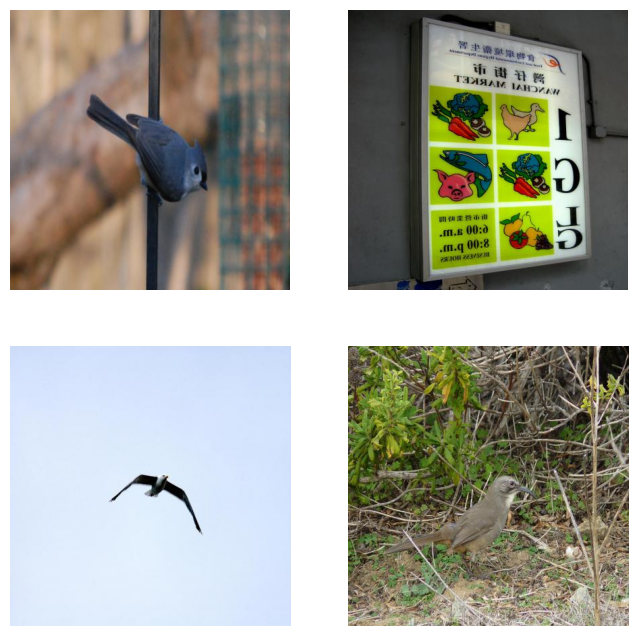

In [ ]:
# understanding the dataset
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

base_dir = "/content/drive/MyDrive/ML Dataset"

for split in ["train", "valid", "test"]:
    path = os.path.join(base_dir, split)
    print(split, os.listdir(path))

counts = {}
for cls in ["bird", "drone"]:
    counts[cls] = len(os.listdir(os.path.join(base_dir, "train", cls)))

print(counts)

sample_path = os.path.join(base_dir, "train", "bird")
imgs = os.listdir(sample_path)[:4]

plt.figure(figsize=(8,8))
for i, img_name in enumerate(imgs):
    img = Image.open(os.path.join(sample_path, img_name))
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [ ]:
# data preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1/255)
val_gen = ImageDataGenerator(rescale=1/255)

train_path = base_dir + "/train"
val_path = base_dir + "/valid"
test_path = base_dir + "/test"

train_data = train_gen.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode="binary")
val_data = val_gen.flow_from_directory(val_path, target_size=(224,224), batch_size=32, class_mode="binary")

# data augumentation
aug_gen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_data = aug_gen.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode="binary")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 2662 images belonging to 2 classes.


In [ ]:
# custom CNN model building
from tensorflow.keras import layers, models


cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation="relu"))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(128, (3,3), activation="relu"))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Flatten())
cnn.add(layers.Dense(128, activation="relu"))
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(1, activation="sigmoid"))

cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# Transfer learning model building (EfficientNet)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))

for l in base_model.layers:
    l.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# training the models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early = EarlyStopping(patience=3, restore_best_weights=True)

cnn_hist = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early]
)

tl_hist = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 883s 10s/step - accuracy: 0.6150 - loss: 0.7281 - val_accuracy: 0.6697 - val_loss: 0.6132
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.7021 - loss: 0.5686 - val_accuracy: 0.7376 - val_loss: 0.5308
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.7453 - loss: 0.5091 - val_accuracy: 0.7376 - val_loss: 0.4939
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 387s 5s/step - accuracy: 0.7457 - loss: 0.5078 - val_accuracy: 0.7579 - val_loss: 0.4682
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 385s 5s/step - accuracy: 0.7874 - loss: 0.4398 - val_accuracy: 0.8145 - val_loss: 0.4413
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.8002 - loss: 0.4183 - val_accuracy: 0.8077 - val_loss: 0.4403
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 390s 5s/step - accuracy: 0.8193 - loss: 0.4005 - val_accuracy: 0.8100 - val_loss: 0.4490
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 405s 5s/step - accuracy: 0.8253 - loss: 0.3960 - val_accuracy: 0.8213 - 

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step
CNN
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       121
           1       0.80      0.84      0.82        94

    accuracy                           0.84       215
   macro avg       0.83      0.84      0.84       215
weighted avg       0.84      0.84      0.84       215

[[101  20]
 [ 15  79]]
Transfer Learning
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       121
           1       0.00      0.00      0.00        94

    accuracy                           0.56       215
   macro avg       0.28      0.50      0.36       215
weighted avg       0.32      0.56      0.41       215

[[121   0]
 [ 94   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


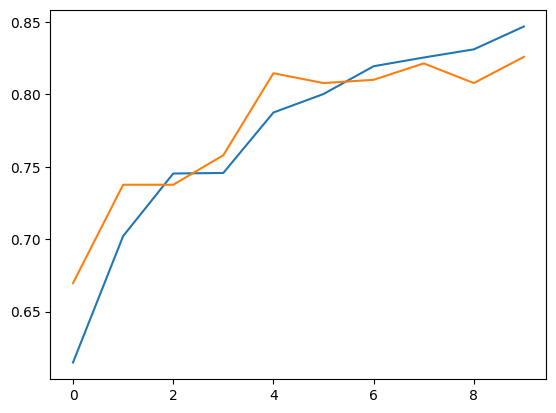

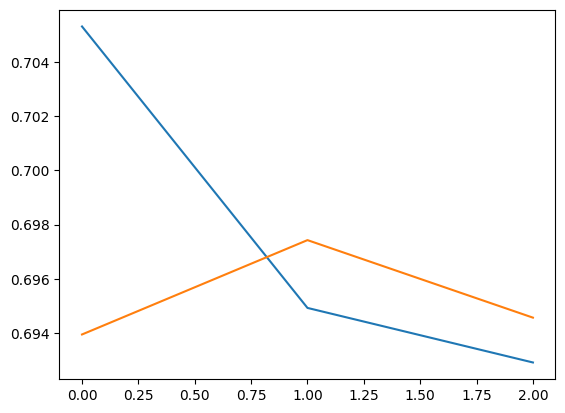

CNN: 0.8257918357849121
TL: 0.49095022678375244


In [ ]:
# evaluation of models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_data = val_gen.flow_from_directory(test_path, target_size=(224,224), batch_size=32, class_mode="binary", shuffle=False)

cnn_preds = cnn.predict(test_data)
tl_preds = tl_model.predict(test_data)

cnn_labels = (cnn_preds > 0.5).astype(int)
tl_labels = (tl_preds > 0.5).astype(int)

print("CNN")
print(classification_report(test_data.classes, cnn_labels))
print(confusion_matrix(test_data.classes, cnn_labels))

print("Transfer Learning")
print(classification_report(test_data.classes, tl_labels))
print(confusion_matrix(test_data.classes, tl_labels))

# plots
plt.plot(cnn_hist.history['accuracy'])
plt.plot(cnn_hist.history['val_accuracy'])
plt.show()

plt.plot(tl_hist.history['loss'])
plt.plot(tl_hist.history['val_loss'])
plt.show()

# model comparison
cnn_acc = max(cnn_hist.history['val_accuracy'])
tl_acc = max(tl_hist.history['val_accuracy'])

if tl_acc > cnn_acc:
    tl_model.save("/content/drive/MyDrive/best_model.h5")
else:
    cnn.save("/content/drive/MyDrive/best_model.h5")

print("CNN:", cnn_acc)
print("TL:", tl_acc)

# YOLOv8

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import necessary libraries for YOLO
!pip install ultralytics

In [ ]:
# path verification
import os

base = "/content/drive/MyDrive/YOLO Dataset"

for root, dirs, files in os.walk(base):
    if "images" in dirs:
        print(root)

/content/drive/MyDrive/YOLO Dataset/valid
/content/drive/MyDrive/YOLO Dataset/test
/content/drive/MyDrive/YOLO Dataset/train


In [ ]:
# create YAML
cfg = """
train: /content/drive/MyDrive/YOLO Dataset/train/images
val: /content/drive/MyDrive/YOLO Dataset/valid/images

nc: 2
names: ['bird','drone']
"""

with open("data.yaml", "w") as f:
    f.write(cfg)

In [ ]:
# Model training - YOLO
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=5,
    imgsz=640
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf1662938f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
# save to drive
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/yolo_best.pt"
)

'/content/drive/MyDrive/yolo_best.pt'

In [ ]:
model.val()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.7±2.1 ms, read: 1.4±0.5 MB/s, size: 23.4 KB)
val: Scanning /content/drive/MyDrive/YOLO Dataset/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 64.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 4.6s/it 2:08
                   all        448        663      0.791      0.681       0.76      0.441
                  bird        217        414      0.808      0.479      0.625      0.326
                 drone        225        249      0.774      0.884      0.895      0.556
Speed: 2.0ms preprocess, 264.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf197f1b800>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# inference
model("/content/drive/MyDrive/YOLO Dataset/valid/images", save=True)


image 1/448 /content/drive/MyDrive/YOLO Dataset/valid/images/000b4796f7fb05df_jpg.rf.424af2aea307cff3f4ecfc227b17493e.jpg: 640x640 1 bird, 489.3ms
image 2/448 /content/drive/MyDrive/YOLO Dataset/valid/images/001efa9e9adb51ed_jpg.rf.49044b2928813467b4b523de6e374592.jpg: 640x640 1 bird, 471.6ms
image 3/448 /content/drive/MyDrive/YOLO Dataset/valid/images/002e5a8b293ba55a_jpg.rf.5ba62ed8edc692be4f09e09b093f2200.jpg: 640x640 2 birds, 530.9ms
image 4/448 /content/drive/MyDrive/YOLO Dataset/valid/images/003fc1e9d6110dcc_jpg.rf.1a175dcb19e1247f91035c3401260557.jpg: 640x640 1 bird, 969.8ms
image 5/448 /content/drive/MyDrive/YOLO Dataset/valid/images/00570e9f0f6e1db1_jpg.rf.74c4b8f9a5883a03baf79e60f1a2dacb.jpg: 640x640 1 bird, 1611.0ms
image 6/448 /content/drive/MyDrive/YOLO Dataset/valid/images/00584b3a4e064d09_jpg.rf.5879fc9d620fda58e6498df276bd2733.jpg: 640x640 1 bird, 914.0ms
image 7/448 /content/drive/MyDrive/YOLO Dataset/valid/images/005e061db776d530_jpg.rf.668f00ad63cc7453354b86fad1fcbc

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bird', 1: 'drone'}
 obb: None
 orig_img: array([[[153, 154, 150],
         [159, 160, 156],
         [162, 163, 159],
         ...,
         [173, 171, 160],
         [162, 160, 149],
         [152, 150, 139]],
 
        [[165, 166, 162],
         [172, 173, 169],
         [180, 181, 177],
         ...,
         [173, 171, 160],
         [171, 169, 158],
         [169, 167, 156]],
 
        [[176, 175, 171],
         [177, 176, 172],
         [178, 177, 173],
         ...,
         [155, 153, 142],
         [162, 160, 149],
         [168, 166, 155]],
 
        ...,
 
        [[166, 167, 165],
         [167, 168, 166],
         [169, 170, 168],
         ...,
         [169, 166, 161],
         [174, 171, 166],
         [176, 173, 168]],
 
        [[171, 172, 170],
         [171, 172, 170],
         [171, 172, 170],
         ...,
        

In [ ]:
import os

img_dir = "/content/drive/MyDrive/YOLO Dataset/valid/images"
img = os.listdir(img_dir)[0]

model(os.path.join(img_dir, img), save=True)


image 1/1 /content/drive/MyDrive/YOLO Dataset/valid/images/pic_511_jpg.rf.a6e8b99d6b566d2d161456fa725d345e.jpg: 640x640 1 drone, 646.6ms
Speed: 9.6ms preprocess, 646.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bird', 1: 'drone'}
 obb: None
 orig_img: array([[[ 54,  29,   0],
         [ 62,  37,   0],
         [ 72,  49,   4],
         ...,
         [201, 172,  37],
         [201, 172,  37],
         [201, 172,  37]],
 
        [[ 55,  29,   0],
         [ 59,  33,   0],
         [ 67,  43,   1],
         ...,
         [201, 172,  37],
         [201, 172,  37],
         [201, 172,  37]],
 
        [[ 61,  33,   0],
         [ 61,  33,   0],
         [ 62,  36,   0],
         ...,
         [201, 172,  37],
         [201, 172,  37],
         [201, 172,  37]],
 
        ...,
 
        [[141, 107,  14],
         [142, 108,  15],
         [142, 108,  15],
         ...,
         [156, 144,  36],
         [150, 139,  28],
         [145, 134,  22]],
 
        [[141, 107,  14],
         [141, 107,  14],
         [141, 107,  14],
         ...,
        

In [ ]:
print(type(model))

model.save("/content/best_fixed_model.h5")

<class 'ultralytics.models.yolo.model.YOLO'>


# StreamLit Deployment

In [ ]:
pip install streamlit

In [ ]:
import streamlit as st
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from ultralytics import YOLO
import os

clf = load_model("/content/drive/MyDrive/best_classifier.h5")
det = YOLO("/content/drive/MyDrive/yolo_best.pt")

st.title("Aerial Object Classification & Detection")

file = st.file_uploader("Upload an image")

if file:
    img = Image.open(file)
    st.image(img)

    resized = img.resize((224, 224))
    arr = np.array(resized) / 255.0
    arr = arr.reshape(1, 224, 224, 3)

    pred = clf.predict(arr)[0][0]
    label = "Drone" if pred > 0.5 else "Bird"

    st.subheader("Classification")
    st.write(label)
    st.write(f"Confidence: {float(pred):.2f}")

    temp_path = "temp.jpg"
    img.save(temp_path)

    results = det(temp_path)

    for r in results:
        output_img = r.plot()
        st.subheader("Detection")
        st.image(output_img)

OSError: Unable to synchronously open file (file signature not found)